# Tarea Semanal 1

### Julián Galeano Pinazo

Dada la siguiente red circuital:

![Circuito](imagenes/circuitobase.png)

#### 1. Obtener analíticamente la función transferencia $T(s)= \frac{V_2}{V_1}$, y realizar diagramas de polos y ceros, módulo y fase para el caso de $\frac{R_2}{R_1}=1$

Por lo general los circuitos con amplificadores operacionales son mas sencillos de resolver planteando las ecuaciones de nodos. En este caso son dos, ambos nodos con voltaje $V_a$:
$$
\begin{cases}
    V_a(G_1+G_2)-V_1 G_1-V_2 G_2=0 \\
    V_a(sC_1+G_3)-V_1 sC_1 = 0
\end{cases}
$$
Partiendo de la segunda ecuacion podemos despejar $V_a$ y reemplazar en la primera ecuacion:
$$
V_a=V_1 \frac{sC_1}{sC_1+G3}
$$
$$
V_1 \frac{sC_1}{sC_1+G_3} (G_1+G_2) - V_1 G_1 = V_2 G_2 
$$
$$
V_1 \frac{sC_1(G_1+G_2)-G_1(sC_1+G_3)}{sC_1+G_3}=V_2 G_2 \Rightarrow
$$
$$
T(s) = \frac{V_2}{V_1} = \frac{sC1(G_1+G_2)-sC_1 G_1 - G_1 G_3}{G_2(sC_1+G_3)}
$$
$$
T(s) = \frac{sC1 G_2 - G_1 G_3}{G_2(sC_1+G_3)} \tag{1}
$$
$$
T(s) = \frac{C_1 G_2}{C_1 G_2} \frac{s - \frac{G_1 G_3}{C_1 G_2}}{s+\frac{G_3}{C_1}} = \frac{s - \frac{R_2}{R_1}\frac{1}{C_1 R_3}}{s + \frac{1}{C_1 R_3}}
$$
Y para el caso de $\frac{R_2}{R_1}=1$:
$$
T(s) = \frac{s - \frac{1}{C_1 R_3}}{s + \frac{1}{C_1 R_3}}, \quad \omega_0=\frac{1}{C_1 R_3} \tag{2}
$$

Se puede verificar este resultado utilizando el módulo de python Sympy para calculo simbólico:

In [1]:
import sympy as syp

V1, V2, Va = syp.symbols("V1, V2, Va")
G1, G2, G3, C1 = syp.symbols("G1, G2, G3, C1")
S = syp.symbols("S")
so = syp.solve([
        Va*(G1+G2)-V1*G1-V2*G2,
        Va*(S*C1+G3)-V1*S*C1
        ],
        [V1,V2,Va])

T_si = so[V2]/so[V1]
print(T_si)

(C1*G2*S - G1*G3)/(G2*(C1*S + G3))


Esta expresión coincide con la de la ecuación (1)

El módulo y fase de esta transferencia son:

$$
T(j\omega) = \frac{-\omega_0 + j\omega}{\omega_0 + j\omega} \Rightarrow \left| T(j\omega) \right| = \frac{\sqrt{(-\omega_0)²+\omega²}}{\sqrt{\omega_0²+\omega²}} = 1
$$
$$
\phi[T(j\omega)] = tg^{-1}\left( \frac{\omega}{-\omega_0} \right) - tg^{-1}\left( \frac{\omega}{\omega_0} \right) = -2 tg^{-1}\left( \frac{\omega}{\omega_0} \right)
$$

A continuación los gráficos de polos y ceros y de respuesta en frecuencia:

<img src="imagenes/dpyc.jpg" width=600>

Una forma mas clara de explicar lo que esta escrito en este gráfico es que, al tener un cero en el semiplano de $\sigma > 0$, este tiene un argumento de $-\pi$ para $\omega = 0$, y el polo en el otro semiplano tiene un argumento igual a 0 en las mismas condiciones, por lo que la respuesta en frecuencia partirá de $\pi$.

<img src="imagenes/fase.jpg" width=600>

La respuesta en frecuencia llega a la mitad de su recorrido en $\omega_0$

#### 2. ¿De qué tipo de filtro se trata? Investigue y comente brevemente qué utilidad podría tener este tipo de circuitos.

Este es un filtro pasa-todo (all-pass filter en ingles). Su caracterísitca principal es que tiene una transferencia de módulo unitario para todas las frecuencias, o por decirlo de otra forma su banda de paso es todo el espectro de frecuencias. En cambio, su respuesta en fase si varía en frecuencia.
Es utilizado para para realizar correcciones de fase en sistemas sin alterar sus respuestas en amplitud, pudiendo compensar sistemas de fase no minima para que pasen a ser de fase mínima. También se usan en efectos de sonido como el "phaser", el cual simula el efecto de los parlantes rotatorios utilizados en los organos Hammond.

#### 3. Proponga una norma de impedancia y frecuencia de forma tal de llegar a una transferencia normalizada (escalada en impedancia y frecuencia).

Dado que $R_1$ y $R_2$ no son relevantes en la transferencia, la norma de impedancia va a ser $\Omega_Z = R_3$
$$
\Rightarrow C=C_1*\Omega_Z = C_1 R_3 \Rightarrow \omega_0 = \frac{1}{C} = \frac{1}{C_1 R_3}
$$

y planteando una norma de frecuencia $\Omega_\omega = \omega_0$: 
$$
T(s\Omega_\omega) = \frac{s\Omega_\omega-\omega_0}{s\Omega_\omega+\omega_0} = \frac{s\omega_0 - \omega_0}{s\omega_0 + \omega_0} = \frac{s-1}{s+1} \Rightarrow
$$
y como también $T(s) = \frac{s-\frac{1}{C}}{s+\frac{1}{C}} \Rightarrow C=1$

No terminé de entender como podría usar Sympy para corroborar esto.

#### 4. Simule numéricamente la función transferencia normalizada en Python.

Se decidió hacer la declaración de la transferencia generalizada para cualquier $\omega_0$, y setear esta en 1. Se utilizó el módulo scipy.signal en lugar del creado para la materia, pytc2, por familiaridad con este, a excepción de la función 'pzmap' que resultó sumamente útil.

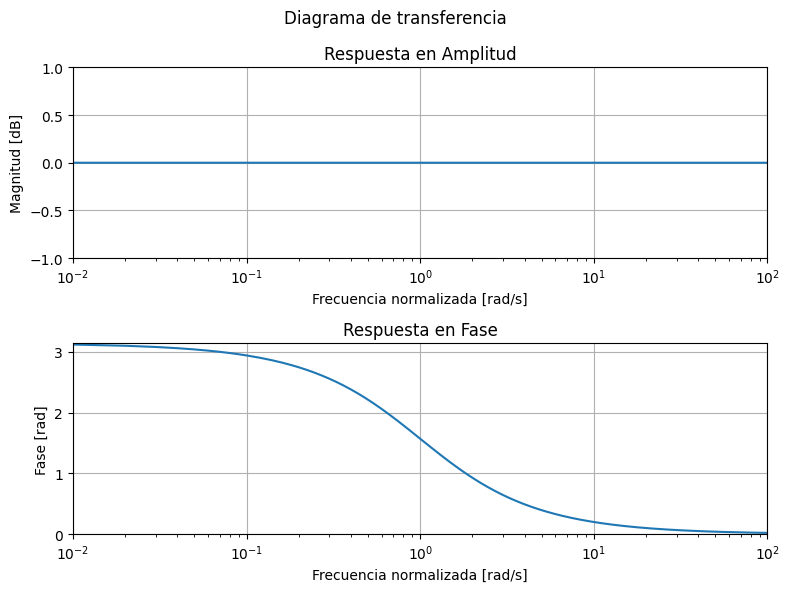

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

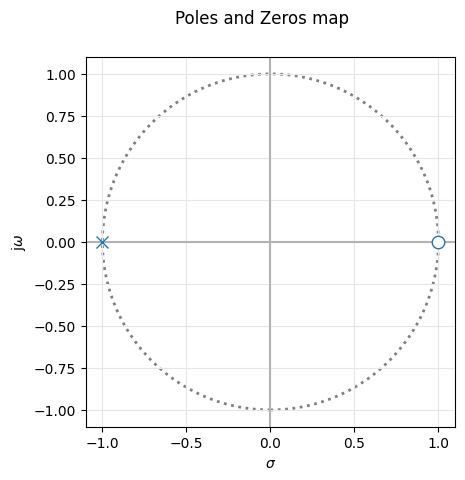

In [4]:
import numpy as np
from scipy.signal import TransferFunction, bode
from pytc2.sistemas_lineales import pzmap
from matplotlib import pyplot as plt

w0 = 1
p = np.array([1, -w0])
q = np.array([1, w0])

T_nu = TransferFunction(p, q)

w=np.arange(0,10**3,0.01)
w, mag, phase = bode(T_nu, w=w)
phase_rad = phase*2*np.pi/360

plt.figure(figsize=(8,6))
plt.suptitle('Diagrama de transferencia')
plt.subplot(211)
plt.semilogx(w, mag)
plt.ylim(-1,1)
plt.xlim(10**-2,10**2)
plt.grid()
plt.title('Respuesta en Amplitud')
plt.xlabel('Frecuencia normalizada [rad/s]')
plt.ylabel('Magnitud [dB]')

plt.subplot(212)
plt.semilogx(w, phase_rad)
plt.ylim(0,np.pi)
plt.xlim(10**-2,10**2)
plt.grid()
plt.title('Respuesta en Fase')
plt.xlabel('Frecuencia normalizada [rad/s]')
plt.ylabel('Fase [rad]')

plt.tight_layout()
plt.show()

pzmap(T_nu)

Se puede verificar que tanto la respuesta en amplitud es unitaria (0 dB) para todo el espectro de frecuencias como que la respuesta en frecuencia parte de $\pi$ y que llega a $\frac{\pi}{2}$ en $\omega=\omega_0$.

#### 5. Obtener una red normalizada que responda a la función hallada en el inciso anterior.

![Red Normalizada](imagenes/circuitonorm.png)

#### 6. Simule la red normalizada en LTSpice y obtenga su respuesta en frecuencia.

En la siguiente imagen se puede ver la simulación de LTSpice que se realizó, tanto el circuito como las directivas utilizadas. Se decidió situar la frecuencia normalizada en 1Hz, el equivalente a $2\pi$ radianes, ya que en LTSpice solo se puede visualizar el eje de frecuencia en esta unidad.

![Circuito LTSpice](imagenes/ltspice_circ.png)

A continuación los resultados de la simulación, con el cursor colocado en la frecuencia $\omega_0$ normalizada:

![Resultados LTSpice](imagenes/ltspice_graf.png)

Se puede observar que la fase en ese punto es de 90°, o $\frac{\pi}{2}$, lo cual coincide con todo lo visto hasta ahora